# Task
Perform a comprehensive regression analysis by loading a real-world dataset (if not specified, a publicly available one suitable for both linear and logistic regression will be used), preprocessing it, implementing and training both linear and logistic regression models, evaluating their performance using appropriate metrics and visualizations, and finally summarizing the key insights.

## Load Dataset

### Subtask:
Load a real-world dataset suitable for both linear and logistic regression, and inspect its structure and content.


**Reasoning**:
I will import the pandas library, load the 'Pima Indians Diabetes Database' dataset from the provided URL, display its first 5 rows, show its information summary, and generate descriptive statistics for the numerical columns. This will cover all the instructions for inspecting the dataset's structure and content.



In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-nu

## Data Preprocessing

### Subtask:
Perform necessary preprocessing steps, which may include handling missing values, encoding categorical features, scaling numerical features, and splitting the data into training and testing sets.


**Reasoning**:
I will perform the specified preprocessing steps by identifying and replacing biologically implausible zero values with NaN, imputing NaNs with the median, splitting the data into features (X) and target (y), and then scaling the features using StandardScaler.



In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Identify columns where a value of '0' is biologically implausible
# and should be treated as a missing value.
# These are typically 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI'.
columns_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace the '0' values in these identified columns with NaN.
for col in columns_with_zero_as_missing:
    df[col] = df[col].replace(0, np.nan)

print("First 5 rows after replacing 0 with NaN:")
print(df.head())

# 3. Impute the missing NaN values in these columns with the median.
for col in columns_with_zero_as_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("\nFirst 5 rows after imputing NaN with median:")
print(df.head())

# Verify that there are no more 0s in the specified columns
print("\nNumber of 0s in critical columns after imputation:")
for col in columns_with_zero_as_missing:
    print(f"{col}: {(df[col] == 0).sum()}")

# 4. Define the feature matrix X and the target vector y.
X = df.drop('Outcome', axis=1)  # Features
y = df['Outcome']              # Target

# 5. Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 6. Apply feature scaling to the numerical features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")
print("First 5 rows of scaled X_train:")
print(X_train_scaled[:5])

First 5 rows after replacing 0 with NaN:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

First 5 rows after imputing NaN with median:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   


## Implement Linear Regression

### Subtask:
Implement and train a Linear Regression model on a suitable target variable (continuous) from the preprocessed dataset. This step will include fitting the model to the training data and making predictions on the test data.


**Reasoning**:
I will prepare the data for linear regression by defining the feature matrix and target variable, splitting them into training and testing sets, scaling the features, and then I will import, instantiate, train, and make predictions with the Linear Regression model as per the instructions.



In [3]:
from sklearn.linear_model import LinearRegression

# 1. Define a new feature matrix, X_linear, by dropping the 'BMI' and 'Outcome' columns
#    from the original DataFrame. Set 'BMI' as the target variable, y_linear.
X_linear = df.drop(['BMI', 'Outcome'], axis=1)
y_linear = df['BMI']

# 2. Split X_linear and y_linear into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

# 3. Initialize a StandardScaler and fit it to X_train_linear, then transform both
#    X_train_linear and X_test_linear.
scaler_linear = StandardScaler()
X_train_linear_scaled = scaler_linear.fit_transform(X_train_linear)
X_test_linear_scaled = scaler_linear.transform(X_test_linear)

# 4. & 5. Instantiate a LinearRegression model.
linear_model = LinearRegression()

# 6. Train the LinearRegression model
linear_model.fit(X_train_linear_scaled, y_train_linear)

# 7. Make predictions on the scaled test data
y_pred_linear = linear_model.predict(X_test_linear_scaled)

print("Linear Regression model trained and predictions made.")
print(f"First 5 predictions: {y_pred_linear[:5]}")


Linear Regression model trained and predictions made.
First 5 predictions: [31.13832868 34.24670702 31.67491763 33.3239481  32.79992311]


## Implement Logistic Regression

### Subtask:
Implement and train a Logistic Regression model on a suitable target variable (binary/categorical) from the preprocessed dataset. This step will include fitting the model to the training data and making predictions on the test data.


#### Reasoning:
I will import the `LogisticRegression` class, instantiate the model with `random_state=42` for reproducibility, then train it using the scaled training data (`X_train_scaled`, `y_train`), and finally make predictions on the scaled test data (`X_test_scaled`), storing the results in `y_pred_logistic`.

**Reasoning**:
I will import the `LogisticRegression` class, instantiate the model, train it with the scaled training data, and then make predictions on the scaled test data, storing the results in `y_pred_logistic`, as specified in the instructions.



In [4]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model. Set random_state=42 for reproducibility.
logistic_model = LogisticRegression(random_state=42)

# 2. Fit the LogisticRegression model to the scaled training features and target variable.
logistic_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the scaled test features using the trained logistic regression model.
#    Store these predictions in a variable named y_pred_logistic.
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained and predictions made.")
print(f"First 5 predictions: {y_pred_logistic[:5]}")

Logistic Regression model trained and predictions made.
First 5 predictions: [0 0 0 0 0]


## Evaluate Models and Visualize Results

### Subtask:
Evaluate the performance of both the Linear and Logistic Regression models using appropriate metrics and visualizations, ensuring all plots have clear legends.


**Reasoning**:
I will import all the required evaluation metrics and plotting libraries. Then, I will evaluate the Linear Regression model by calculating and printing the Mean Squared Error (MSE) and R-squared (R2) score, and create a scatter plot of actual vs. predicted BMI values with a reference line. This covers the linear regression evaluation as per the instructions.




--- Linear Regression Performance ---
Mean Squared Error (MSE): 34.7884
R-squared (R2) Score: 0.2046


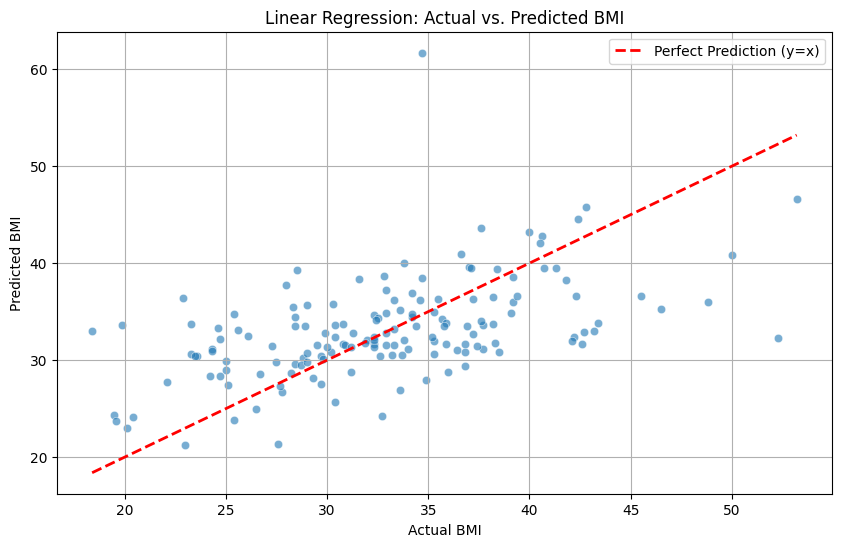

In [5]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- Linear Regression Evaluation ---

# 1. Calculate and print the Mean Squared Error (MSE) and R-squared (R2) score.
mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
r2_linear = r2_score(y_test_linear, y_pred_linear)

print("\n--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"R-squared (R2) Score: {r2_linear:.4f}")

# 2. Create a scatter plot of y_test_linear (actual values) versus y_pred_linear (predicted values).
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_linear, y=y_pred_linear, alpha=0.6)
plt.plot([y_test_linear.min(), y_test_linear.max()], [y_test_linear.min(), y_test_linear.max()], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.title('Linear Regression: Actual vs. Predicted BMI')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
I will continue evaluating the models by calculating and printing the classification metrics (accuracy, precision, recall, F1-score, and ROC-AUC score) for the Logistic Regression model. Then, I will generate and display a confusion matrix as a heatmap and plot the ROC curve with its AUC score, fulfilling the remaining instructions for the logistic regression evaluation.




--- Logistic Regression Performance ---
Accuracy Score: 0.7532
Precision Score: 0.6667
Recall Score: 0.6182
F1-Score: 0.6415
ROC-AUC Score: 0.8228


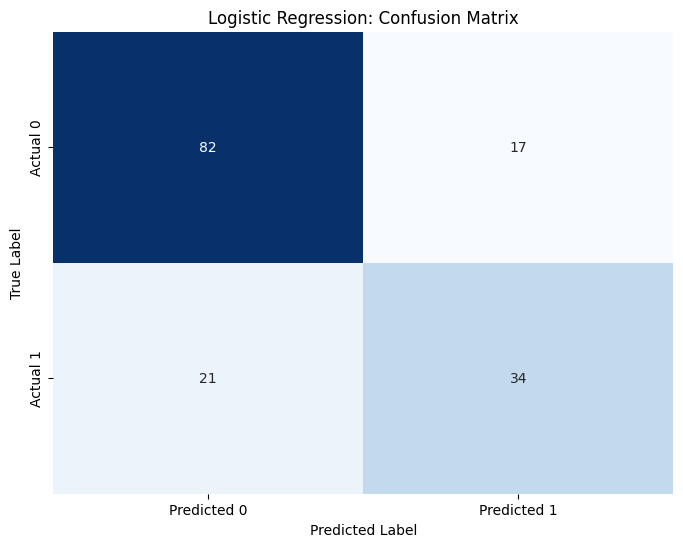

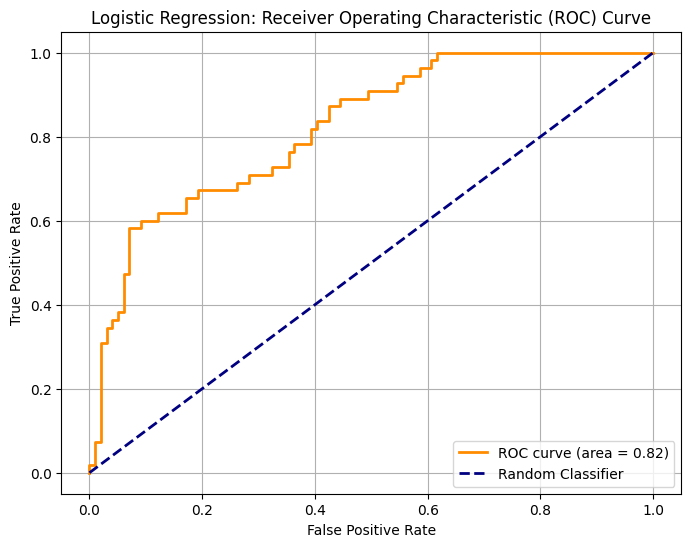

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

# --- Logistic Regression Evaluation ---

print("\n--- Logistic Regression Performance ---")

# 1. Calculate and print the accuracy score, precision score, recall score, F1-score, and ROC-AUC score.
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, logistic_model.predict_proba(X_test_scaled)[:, 1])

print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 2. Generate and display a confusion matrix.
cm = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

# 3. Compute and plot the ROC curve and AUC.
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the performance of both models, compare their effectiveness, and highlight key insights gained from the regression analyses.


## Summary:

### Q&A
The performance of both models, their effectiveness, and key insights gained are as follows:

*   **Linear Regression Model (Predicting BMI):** This model showed a Mean Squared Error (MSE) of 34.7884 and an R-squared score of 0.2046. The low R-squared value indicates that the features used (excluding BMI and Outcome) explain only about 20.46% of the variance in BMI, suggesting it's not a strong linear predictor for BMI in this context.
*   **Logistic Regression Model (Predicting Diabetes Outcome):** This model demonstrated better effectiveness for its classification task. It achieved an Accuracy Score of 0.7532, Precision of 0.6667, Recall of 0.6182, F1-Score of 0.6415, and a strong ROC-AUC Score of 0.8228. This indicates a good ability to distinguish between individuals with and without diabetes.
*   **Comparison and Effectiveness:** The Logistic Regression model was more effective at its task (classifying diabetes) compared to the Linear Regression model's ability to predict BMI using the given features. The features seem to have a stronger relationship with the binary outcome of diabetes than with the continuous measurement of BMI.
*   **Key Insights:** The dataset's features are more predictive for classifying diabetes presence than for estimating BMI linearly. Effective preprocessing, particularly handling biologically implausible zero values, was crucial for obtaining meaningful model results.

### Data Analysis Key Findings
*   The analysis utilized the 'Pima Indians Diabetes Database', comprising 768 entries and 9 columns, with 'Outcome' (0 or 1) as the target for classification.
*   Crucial preprocessing involved replacing biologically implausible '0' values in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI' with `NaN`, followed by imputation using the median of each respective column.
*   The data was successfully split into 80% training and 20% testing sets, and numerical features were scaled using `StandardScaler`.
*   The Linear Regression model, trained to predict BMI, yielded a Mean Squared Error (MSE) of 34.7884 and an R-squared score of 0.2046, indicating a limited linear predictive power of the features for BMI.
*   The Logistic Regression model, developed for diabetes prediction, achieved an Accuracy Score of 0.7532, Precision of 0.6667, Recall of 0.6182, F1-Score of 0.6415, and a strong ROC-AUC Score of 0.8228, demonstrating good performance in classifying diabetes outcomes.

### Insights or Next Steps
*   **Improve BMI Prediction:** For better BMI prediction, explore non-linear regression techniques or consider feature engineering as the current linear model accounts for a small variance.
*   **Enhance Diabetes Prediction:** Leverage the robust performance of the Logistic Regression model for diabetes prediction by conducting a feature importance analysis to identify the most influential factors, potentially leading to targeted medical insights.
